In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from tensorflow.keras import backend as K
K.clear_session()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imblearn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import joblib
import sys
sys.modules['sklearn.externals.joblib'] = joblib
from sklearn.metrics import confusion_matrix,accuracy_score
import pickle

In [4]:
train_df = pd.read_csv('/content/drive/MyDrive/credit_card_fraud_detection/Data/fraudTrain.csv',index_col=0)
test_df = pd.read_csv('/content/drive/MyDrive/credit_card_fraud_detection/Data/fraudTest.csv',index_col=0)

In [40]:
df = pd.concat([train_df,test_df])
df.head(5)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [6]:
print(df.shape)

(1852394, 22)


In [7]:
df.isna().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [8]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,4.173860e+17,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,1.358674e+09,3.853898e+01,-9.022794e+01,5.210015e-03
std,1.309115e+18,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,1.819508e+07,5.105604e+00,1.375969e+01,7.199217e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00
25%,1.800429e+14,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00
50%,3.521417e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00
75%,4.642255e+15,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [9]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1852394 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int6

In [11]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_date']= df['trans_date_trans_time'].dt.strftime('%Y-%m-%d')
df['trans_date'] = pd.to_datetime(df['trans_date'])
df['dob'] = pd.to_datetime(df['dob'])

In [12]:
df = df.drop('trans_date_trans_time',axis=1)
df.head()

,cc_num,merchant,category,amt,first,last,gender,street,city,state,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_date
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019-01-01
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019-01-01
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019-01-01
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019-01-01
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,2019-01-01


In [13]:
for i in df.columns:
  print(i,df[i].unique().size)

cc_num 999
merchant 693
category 14
amt 60616
first 355
last 486
gender 2
street 999
city 906
state 51
zip 985
lat 983
long 983
city_pop 891
job 497
dob 984
trans_num 1852394
unix_time 1819583
merch_lat 1754157
merch_long 1809753
is_fraud 2
trans_date 730


In [14]:
#value count of each columns
for i in df.columns:
  print(i,df[i].value_counts())

cc_num 6538441737335434       4392
30270432095985         4392
6538891242532018       4386
4364010865167176       4386
4642255475285942       4386
                       ... 
4714017207228610634       7
4352307151555405069       7
180097223252063           7
6011732631674654          7
4295296907373             6
Name: cc_num, Length: 999, dtype: int64
merchant fraud_Kilback LLC                        6262
fraud_Cormier LLC                        5246
fraud_Schumm PLC                         5195
fraud_Kuhn LLC                           5031
fraud_Boyer PLC                          4999
                                         ... 
fraud_Douglas, DuBuque and McKenzie      1101
fraud_Treutel-King                       1098
fraud_Satterfield-Lowe                   1095
fraud_Hahn, Douglas and Schowalter       1091
fraud_Ritchie, Bradtke and Stiedemann    1090
Name: merchant, Length: 693, dtype: int64
category gas_transport     188029
grocery_pos       176191
home              175460
shop

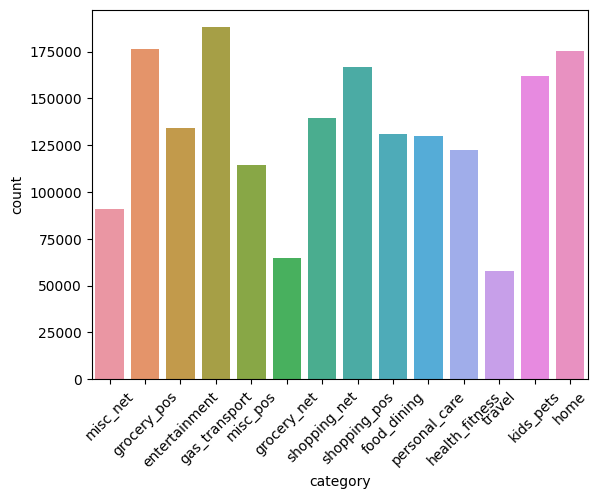

In [15]:
sns.countplot(x=df.category)
plt.xticks(rotation=45)
plt.show()

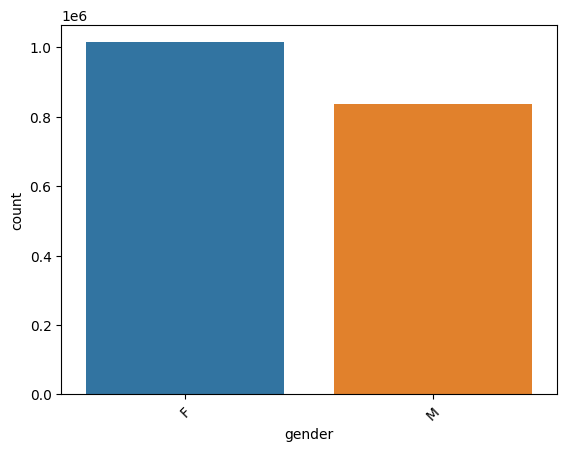

In [16]:
sns.countplot(x=df.gender)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='is_fraud', ylabel='count'>

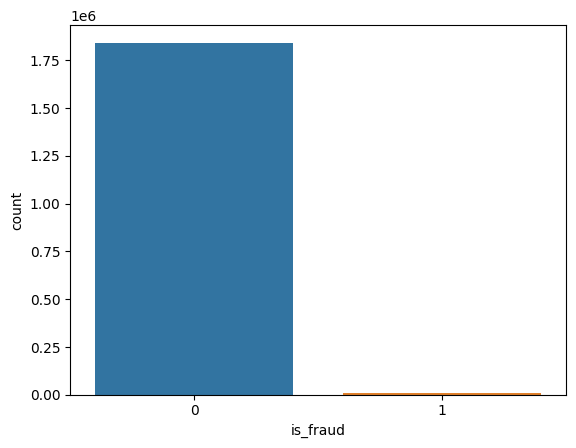

In [17]:
#target class count plot
sns.countplot(x=df['is_fraud'])

In [18]:
#data is imbalanced
df['is_fraud'].value_counts()

0    1842743
1       9651
Name: is_fraud, dtype: int64

In [19]:
df = df.drop(['trans_date','dob','first','last','lat','long','trans_num','street','cc_num','merch_lat','merch_long','unix_time','merchant'],axis='columns')

In [20]:
df.select_dtypes(exclude=['float64','int64']).columns

Index(['category', 'gender', 'city', 'state', 'job'], dtype='object')

In [21]:
df['category'] = df['category'].replace(',','')
df['gender'] = df['gender'].replace(',','')
df['city'] = df['city'].replace(',','')
df['state'] = df['state'].replace(',','')
df['job'] = df['job'].replace(',','')

In [22]:
col = ['category', 'gender', 'city', 'state', 'job']
categoryle = LabelEncoder()
genderle = LabelEncoder()
cityle = LabelEncoder()
statele = LabelEncoder()
joble = LabelEncoder()

In [23]:
df['category'] =  categoryle.fit_transform(df['category'])
df['gender'] =  genderle.fit_transform(df['gender'])
df['city'] =  cityle.fit_transform(df['city'])
df['state'] =  statele.fit_transform(df['state'])
df['job'] =  joble.fit_transform(df['job'])

In [39]:
df.head()

,category,amt,gender,city,state,zip,city_pop,job,is_fraud
0,8,4.97,0,532,27,28654,3495,372,0
1,4,107.23,0,619,47,99160,149,431,0
2,0,220.11,1,474,13,83252,4154,308,0
3,2,45.00,1,84,26,59632,1939,330,0
4,9,41.96,1,217,45,24433,99,116,0


<Axes: >

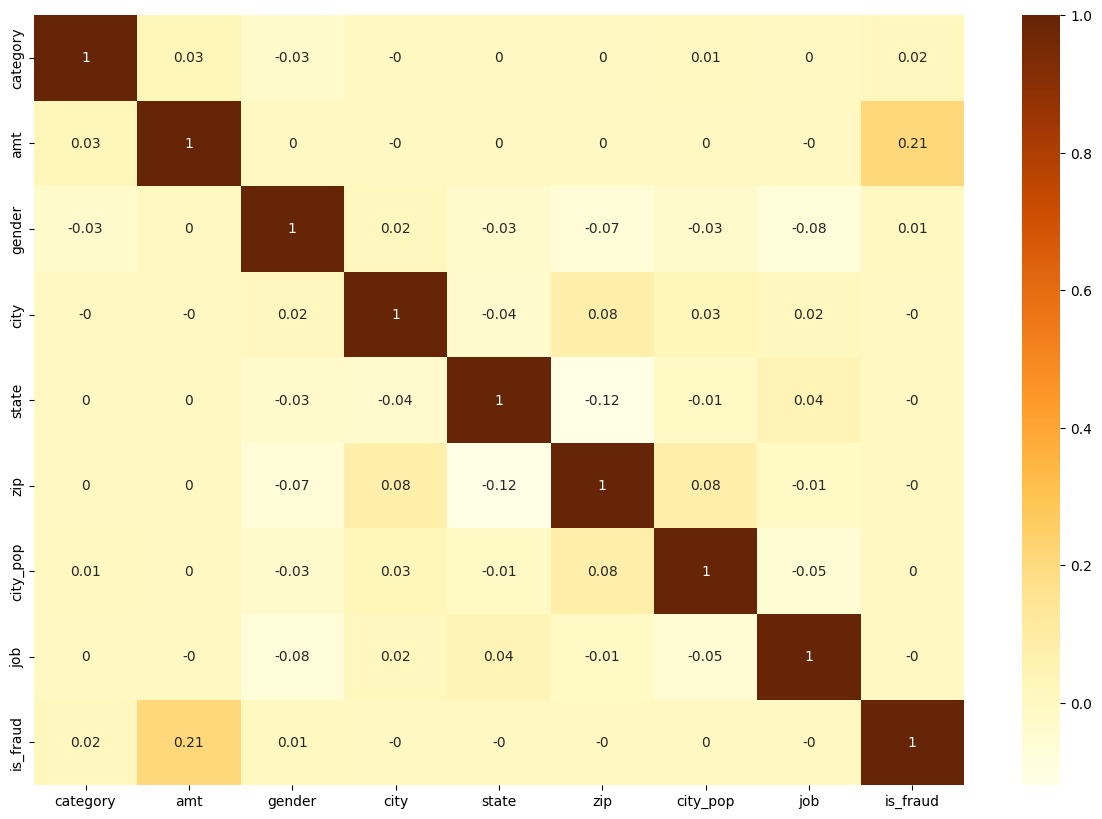

In [25]:
correlation = df.corr().round(2)
plt.figure(figsize = (15,10))
sns.heatmap(correlation, annot = True, cmap = 'YlOrBr')

In [26]:
X = df.drop('is_fraud',axis='columns')
Y = df['is_fraud']

In [27]:
#balancing the dataset using smote oversample
oversample = SMOTE()
X_s, Y_s = oversample.fit_resample(X,Y)

In [28]:
print(X_s.shape)

(3685486, 8)


<Axes: xlabel='is_fraud', ylabel='count'>

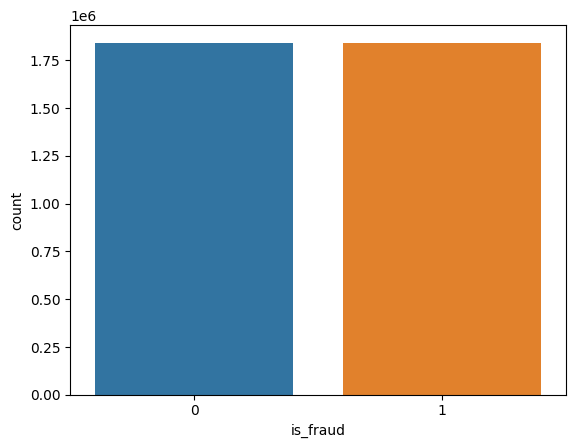

In [29]:
sns.countplot(x=Y_s)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_s,Y_s,test_size=0.2)

Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy Score:  0.5300299281777999


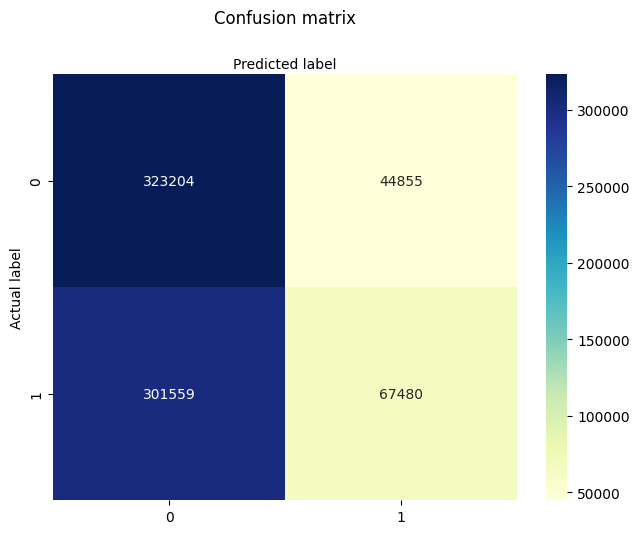

              precision    recall  f1-score   support

           0       0.52      0.88      0.65    368059
           1       0.60      0.18      0.28    369039

    accuracy                           0.53    737098
   macro avg       0.56      0.53      0.47    737098
weighted avg       0.56      0.53      0.47    737098



In [31]:
#Logistic Regression
lg_model = LogisticRegression(max_iter=10)
lg = lg_model
lg.fit(X_train,y_train)
y_pred = lg.predict(X_test)
#accuracy score
print("Accuracy Score: ",accuracy_score(y_test,y_pred))
#confusion Matrix
matrix =confusion_matrix(y_test, y_pred)
class_names=[1,2,3,4]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()
#Classification Report
print(classification_report(y_test, y_pred))

Decision Tree Classifier

Accuracy Score:  0.854803567503914


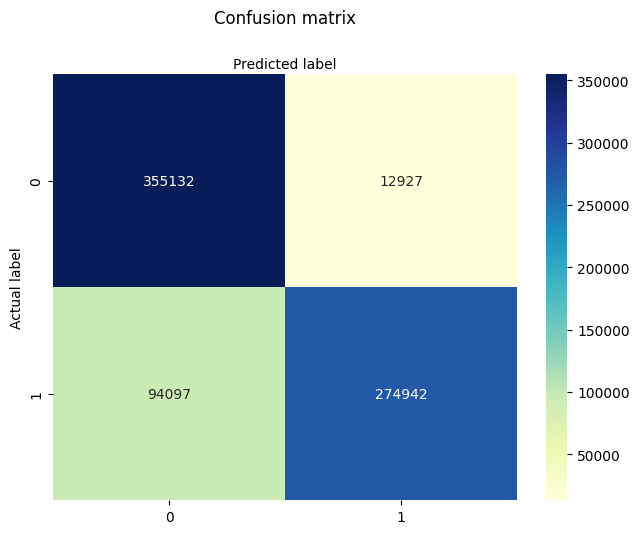

              precision    recall  f1-score   support

           0       0.79      0.96      0.87    368059
           1       0.96      0.75      0.84    369039

    accuracy                           0.85    737098
   macro avg       0.87      0.85      0.85    737098
weighted avg       0.87      0.85      0.85    737098



In [32]:
decision_tree_model = DecisionTreeClassifier(criterion='gini',max_depth=1, min_samples_split=2, random_state=0)
dt = decision_tree_model
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)
#accuracy score
print("Accuracy Score: ",accuracy_score(y_test,y_pred))
#confusion Matrix
matrix =confusion_matrix(y_test, y_pred)
class_names=[1,2,3,4]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()
#Classification Report
print(classification_report(y_test, y_pred))

Random Forest Classifier

Accuracy Score:  0.9662500780086231


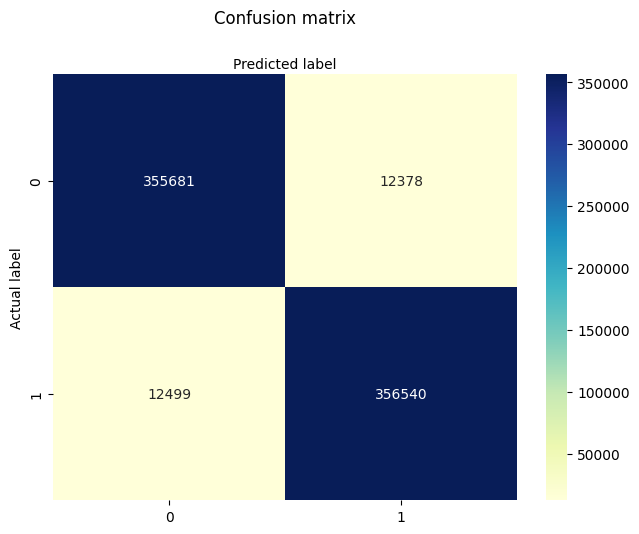

              precision    recall  f1-score   support

           0       0.97      0.97      0.97    368059
           1       0.97      0.97      0.97    369039

    accuracy                           0.97    737098
   macro avg       0.97      0.97      0.97    737098
weighted avg       0.97      0.97      0.97    737098



In [33]:
#Random Forest
random_forest_model = RandomForestClassifier(n_estimators=10, criterion='gini', max_depth=100, min_samples_split=10,random_state=0)
rf = random_forest_model
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
#accuracy score
print("Accuracy Score: ",accuracy_score(y_test,y_pred))
#confusion Matrix
matrix =confusion_matrix(y_test, y_pred)
class_names=[1,2,3,4]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()
#Classification Report
print(classification_report(y_test, y_pred))

In [35]:
filename = '/content/drive/MyDrive/credit_card_fraud_detection/best_model.sav'
pickle.dump(rf, open(filename, 'wb'))